# 01 · micrograd(code-along)

Karpathy 第 1 集:从零手搓自动微分引擎 + backprop。

**怎么做**:跟着视频自己一行行敲,疯狂暂停/回退。卡住了再对照官方:
`~/code/nn-zero-to-hero/lectures/micrograd/micrograd_lecture_first_half_roughly.ipynb`

- 视频:https://www.bilibili.com/video/BV1mqrTBvEaf/
- 上半场 = `Value` 对象 + 计算图 + backward();下半场 = 拿它搭个 MLP
- graphviz 已装好(画计算图用),torch 仅结尾对照时用

/Users/qinzhehan/.venvs/ml312/bin/python


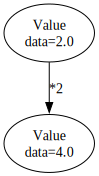

In [5]:
# 环境自检:① kernel 是 ml312 吗  ② graphviz 能在 notebook 里画出来吗
import sys; print(sys.executable)   # 路径应含 /.venvs/ml312/
from graphviz import Digraph
g = Digraph()
g.node('a', 'Value\ndata=2.0'); g.node('b', 'Value\ndata=4.0'); g.edge('a', 'b', '*2')
g   # 这一格应直接显示一张小图。显示出来 = 可视化管线全通,可以开搞 ↓

In [6]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
# 从这里开始跟着 Karpathy 敲 ↓
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value:(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+', '')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*', '')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}' )
        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward
        
        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other ** -1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
    
        return out

    def backward(self):
        self.grad = 1.0
        topo = []
        visited = set()
        def buildtopo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    buildtopo(child)
                topo.append(v)

        buildtopo(self)
        for child in reversed(topo):
            child._backward()

In [8]:
a = Value(2)
b = Value(4.0)
a-b

Value:(data=-2.0)

In [9]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f  }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [10]:
draw_dot(L)

NameError: name 'L' is not defined

In [ ]:
L.grad=1.0
f.grad=4.0
d.grad=-2.0
c.grad=-2.0
e.grad=-2.0
b.grad=-4.0
a.grad=6

In [ ]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad

e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
L = d*f; L.label = L

print(L.data)

-7.286496


In [ ]:
def lol(): 
    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label = 'd'
    f = Value(data=-2.0, label='f')
    L = d*f; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label = 'd'
    f = Value(data=-2.0, label='f')
    L = d*f; L.label='L'
    L2 = L.data+h

    print((L2-L1)/h)

lol()

1.000000000000334


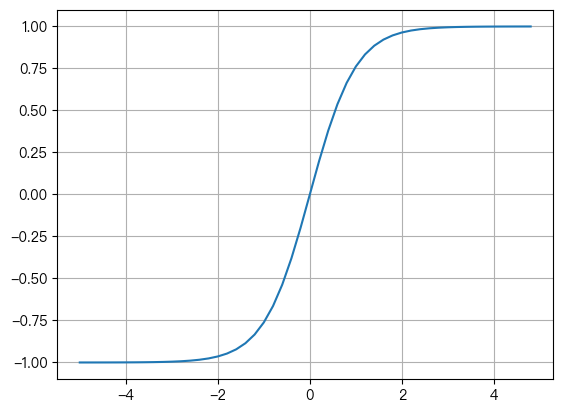

In [ ]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [ ]:
#input x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weight w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.8813735870195432,label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh(); o.label='o'
o.backward()

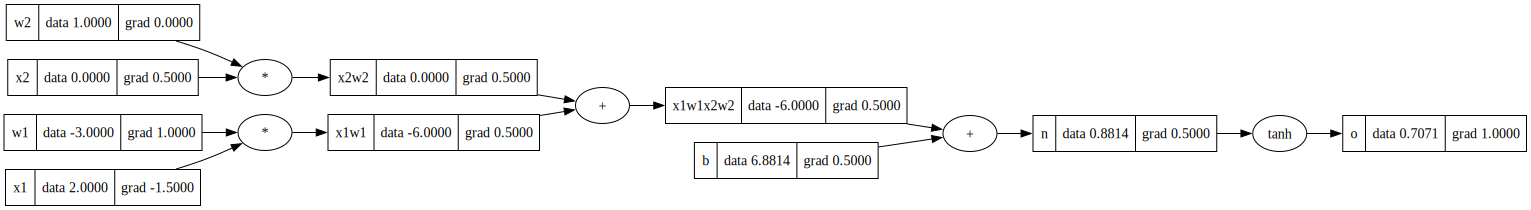

In [ ]:
draw_dot(o)

In [ ]:
topo = []
visited = set()
def buildtopo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            buildtopo(child)
        topo.append(v)

buildtopo(o)
topo

[Value:(data=6.881373587019543),
 Value:(data=1.0),
 Value:(data=0.0),
 Value:(data=0.0),
 Value:(data=2.0),
 Value:(data=-3.0),
 Value:(data=-6.0),
 Value:(data=-6.0),
 Value:(data=0.8813735870195432),
 Value:(data=0.7071067811865476)]

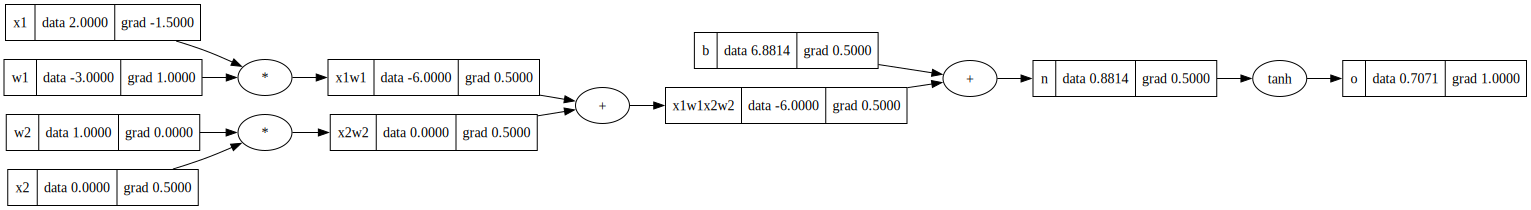

In [ ]:
o.grad = 1.0
for node in reversed(topo):
    node._backward()

draw_dot(o)

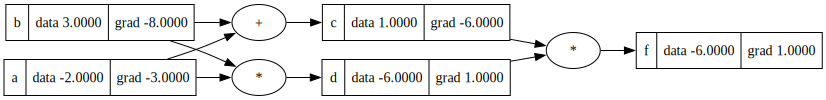

In [ ]:
a = Value(-2, label='a')
b = Value(3, label='b')
d = a * b; d.label = 'd'
c = a + b; c.label = 'c'
f = d * c; f.label = 'f'
f.grad = 1
f.backward()

draw_dot(f)

In [ ]:
#input x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weight w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.8813735870195432,label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1x2w2'
n = x1w1x2w2+b; n.label='n'
# -----
e = (2*n).exp()
o = (e-1)/(e+1)
# ----
o.label = 'o'
o.backward()

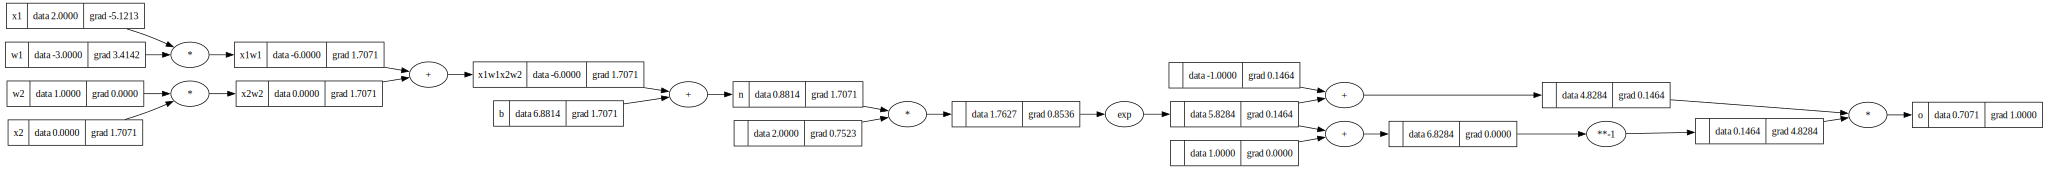

In [ ]:
draw_dot(o)

In [ ]:
import torch

In [ ]:
x1 = torch.Tensor([2.0]).double()   ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()   ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()   ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()   ; w2.requires_grad = True
b = torch.Tensor([6.88137]).double()   ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071050214706146
---
x2 0.5000024886110417
w2 0.0
x1 -1.500007465833125
w1 1.0000049772220834


In [ ]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] 
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        #print(list(zip(self.w,x)))
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters() ]
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x 

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters() ]

In [11]:
x = [2.0,3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

NameError: name 'MLP' is not defined

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [ 3.0, -1.0, 0.5],
    [0.5,1.0,1.0],
    [1.0,1.0, -1.0],
]
ys = [1.0,-1.0,-1.0,1.0]
ys

[1.0, -1.0, -1.0, 1.0]

In [ ]:
for k in range(100):
      # forward
      ypred = [n(x) for x in xs]
      loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

      # backward
      for p in n.parameters():
          p.grad = 0.0
      loss.backward()

      # update
      for p in n.parameters():
          p.data += -0.01 * p.grad

      print(k, loss.data)

NameError: name 'n' is not defined